<a href="https://colab.research.google.com/github/jayeshkoli-1402/ML-LAB/blob/main/ML_Lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.metrics import confusion_matrix, r2_score, root_mean_squared_error, mean_squared_error

# data collection

In [ ]:
data = {

"Study_hours" : [1,2,3,4,5,6,7,8,9,10],
"Attendance" : [60,85,70,95,65,80,90,75,88,72],
"Marks" : [32,42,47,58,61,67,76,79,88,91]

}

In [ ]:
df = pd.DataFrame(data)
df

,Study_hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


# EDA and Preprocessing

In [ ]:
print("First five rows: ")
df.head(5)

First five rows: 


,Study_hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61


In [ ]:
print("Shape : ")
df.shape

Shape : 


(10, 3)

In [ ]:
print("Info: ")
df.info()

Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [ ]:
print("Statical Analysis: ")
df.describe()

Statical Analysis: 


,Study_hours,Attendance,Marks
count,10.00000,10.000000,10.000000
mean,5.50000,78.000000,64.100000
std,3.02765,11.489125,19.790289
min,1.00000,60.000000,32.000000
25%,3.25000,70.500000,49.750000
50%,5.50000,77.500000,64.000000
75%,7.75000,87.250000,78.250000
max,10.00000,95.000000,91.000000


In [ ]:
print("Check NULL Values: ")
df.isnull().sum()

Check NULL Values: 


,0
Study_hours,0
Attendance,0
Marks,0


In [ ]:
print("Duplicate Values: ")
df.duplicated().sum()

Duplicate Values: 


np.int64(0)

In [ ]:
print("Drop Duplicate: ")
df.drop_duplicates()

Drop Duplicate: 


,Study_hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


In [ ]:
df_corr = df.corr()
df_corr

,Study_hours,Attendance,Marks
Study_hours,1.000000,0.245955,0.994877
Attendance,0.245955,1.000000,0.331320
Marks,0.994877,0.331320,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

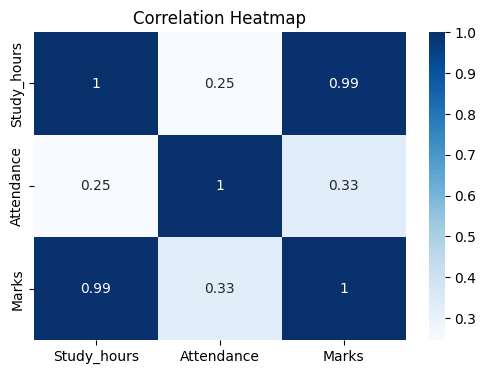

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")

# Simple Linier Regression using scikit-learn

In [ ]:
x = df[['Study_hours']]
x

,Study_hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
y = df['Marks']
y

,Marks
0,32
1,42
2,47
3,58
4,61
5,67
6,76
7,79
8,88
9,91


# Model Building

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=2)

In [ ]:
x_train

,Study_hours
0,1
7,8
2,3
3,4
6,7
9,10
8,9


In [ ]:
y_train

,Marks
0,32
7,79
2,47
3,58
6,76
9,91
8,88


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)
y_pred

array([60.74159664, 41.1092437 , 67.28571429])

In [ ]:
y_test

,Marks
4,61
1,42
5,67


In [ ]:
y_pred

array([60.74159664, 41.1092437 , 67.28571429])

In [ ]:
print(f"Intercept: {model.intercept_}")
print(f"Slope: {model.coef_}")


Intercept: 28.02100840336135
Slope: [6.54411765]


## **SLR Equation: **

marks = (6.54 * Study_hours) + 28.02

# Model Evaluation

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: 0.9972352688629268
RMSE: 0.5603129306308141


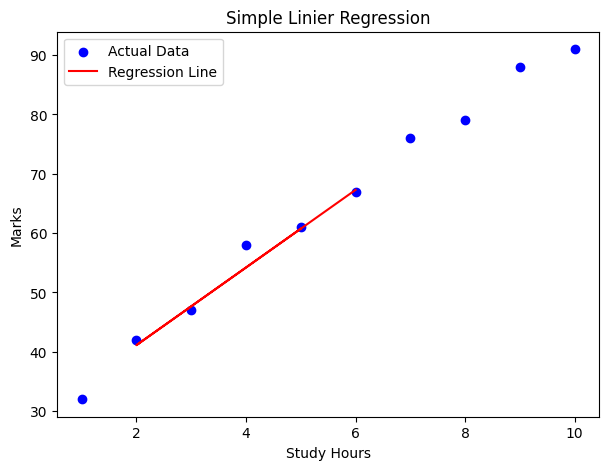

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(x,y,color="blue", label="Actual Data")
plt.plot(x_test,y_pred,color="red", label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Simple Linier Regression")
plt.legend()
plt.show()

# Residual Plot

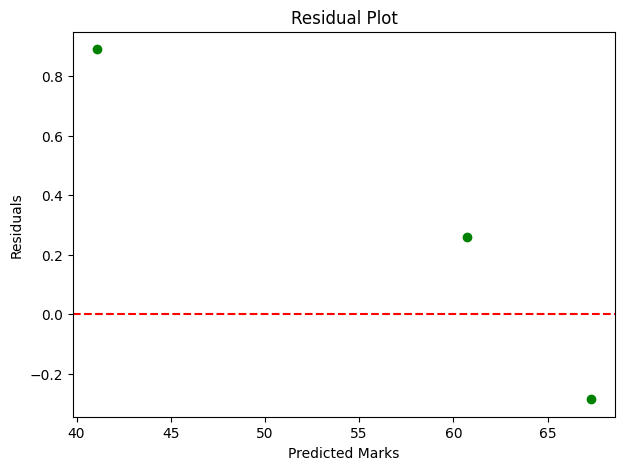

In [ ]:
from matplotlib.lines import lineStyles
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, color="green")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# B] Simple Liner Regression By using Numpy

In [ ]:
x = df['Study_hours'].values
y = df['Marks'].values

In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y)

In [ ]:
m = np.sum((x-x_mean) * (y-y_mean)/np.sum((x-x_mean)**2))

b = y_mean - m*x_mean

print(f"Slope: {m}")
print(f"Intercept: {b}")

Slope: 6.503030303030303
Intercept: 28.33333333333333


In [ ]:
y_pred_numpy = m*x+b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])